# Compare R-squared Values With and Without Ribosomal Genes

This notebook matches the shared CSV files in `../R_Squareds` and `./R_Squareds`, then plots pairwise comparisons for each organ using the labels `scMLEAge` and `scMLEAge without ribosomal genes`.

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.titlesize": 18,
    "axes.labelsize": 15,
    "xtick.labelsize": 11,
    "ytick.labelsize": 12,
    "legend.fontsize": 9,
})

In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "R_Squareds").exists() and (candidate / "Ribosomal_Gene_Study" / "R_Squareds").exists():
            return candidate
    raise FileNotFoundError("Could not locate the repository root from the current working directory.")


REPO_ROOT = find_repo_root(Path.cwd())
BASE_DIR = REPO_ROOT / "R_Squareds"
NO_RIBO_DIR = REPO_ROOT / "Ribosomal_Gene_Study" / "R_Squareds"

BASE_LABEL = "scMLEAge"
NO_RIBO_LABEL = "scMLEAge without ribosomal genes"


def canonical_dataset_name(path: Path) -> str:
    name = path.stem.replace("_r_squared_summary", "")
    name = re.sub(r"_droplet$", "", name)
    return re.sub(r"[^a-z0-9]+", "", name.lower())


def display_dataset_name(path: Path) -> str:
    name = path.stem.replace("_r_squared_summary", "")
    name = re.sub(r"_droplet$", "", name)
    return name.replace("_", " ")


def build_file_map(directory: Path) -> dict:
    return {canonical_dataset_name(path): path for path in sorted(directory.glob("*_r_squared_summary.csv"))}


base_files = build_file_map(BASE_DIR)
no_ribo_files = build_file_map(NO_RIBO_DIR)
shared_keys = sorted(set(base_files) & set(no_ribo_files))

dataset_table = pd.DataFrame({
    "dataset_key": shared_keys,
    "dataset": [display_dataset_name(base_files[key]) for key in shared_keys],
    "base_csv": [base_files[key].name for key in shared_keys],
    "no_ribo_csv": [no_ribo_files[key].name for key in shared_keys],
})

dataset_table

,dataset_key,dataset,base_csv,no_ribo_csv
0,bladder,Bladder,Bladder_r_squared_summary.csv,Bladder_r_squared_summary.csv
1,bonemarrow,Bone-Marrow,Bone-Marrow_r_squared_summary.csv,Bone-Marrow_r_squared_summary.csv
2,brain,Brain,Brain_r_squared_summary.csv,Brain_r_squared_summary.csv
3,heart,Heart,Heart_r_squared_summary.csv,Heart_r_squared_summary.csv
4,kidney,Kidney,Kidney_r_squared_summary.csv,Kidney_r_squared_summary.csv
5,limbmuscle,Limb-Muscle,Limb-Muscle_r_squared_summary.csv,Limb-Muscle_r_squared_summary.csv
6,liver,Liver,Liver_r_squared_summary.csv,Liver_r_squared_summary.csv
7,lung,Lung,Lung_r_squared_summary.csv,Lung_r_squared_summary.csv


In [14]:
def load_r_squared_csv(path: Path, value_name: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    celltype_col = df.columns[0]
    return (
        df.rename(columns={celltype_col: "celltype", "R_squared": value_name})
          [["celltype", value_name]]
          .assign(celltype=lambda x: x["celltype"].astype(str))
    )


def get_comparison_df(dataset_key: str) -> pd.DataFrame:
    base_df = load_r_squared_csv(base_files[dataset_key], BASE_LABEL)
    no_ribo_df = load_r_squared_csv(no_ribo_files[dataset_key], NO_RIBO_LABEL)

    comparison = base_df.merge(no_ribo_df, on="celltype", how="inner")
    comparison["dataset"] = display_dataset_name(base_files[dataset_key])
    comparison["display_label"] = comparison["dataset"] + "\n" + comparison["celltype"]
    comparison["delta"] = comparison[NO_RIBO_LABEL] - comparison[BASE_LABEL]
    return comparison[["dataset", "celltype", "display_label", BASE_LABEL, NO_RIBO_LABEL, "delta"]]


def get_all_comparisons(dataset_keys: list[str]) -> pd.DataFrame:
    comparisons = [get_comparison_df(dataset_key) for dataset_key in dataset_keys]
    if not comparisons:
        raise ValueError("No dataset comparisons were found.")
    return pd.concat(comparisons, ignore_index=True)


def plot_combined_r_squared_comparison(comparison_df: pd.DataFrame, output_path: Path, dpi: int = 600):
    fig_width = 16
    fig, ax = plt.subplots(figsize=(fig_width, 8))

    x = np.arange(len(comparison_df))
    width = 0.38
    colors = ["#5B7C99", "#D06A6A"]

    bars_base = ax.bar(x - width / 2, comparison_df[BASE_LABEL], width=width, color=colors[0], label=BASE_LABEL)
    bars_no_ribo = ax.bar(x + width / 2, comparison_df[NO_RIBO_LABEL], width=width, color=colors[1], label=NO_RIBO_LABEL)

    ax.set_title("Model Performance Comparison With and Without Ribosomal Genes", pad=18)
    ax.set_ylabel("R_squared")
    ax.set_xlabel("Dataset and Cell Type")
    ax.set_xticks(x)
    ax.set_xticklabels(comparison_df["display_label"], rotation=55, ha="right")
    ax.set_ylim(0, 1.02)
    ax.legend(title="Model", loc="upper left", fontsize=9, title_fontsize=10, borderpad=0.35, labelspacing=0.3, handlelength=1.5)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    for bars in (bars_base, bars_no_ribo):
        for bar in bars:
            height = bar.get_height()
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                min(height + 0.008, 1.0),
                f"{height:.2f}",
                ha="center",
                va="bottom",
                fontsize=6,
            )

    fig.tight_layout()
    fig.savefig(output_path, dpi=dpi, bbox_inches="tight")
    plt.show()
    return fig, ax


,dataset,celltype,display_label,scMLEAge,scMLEAge without ribosomal genes,delta
0,Bladder,bladder urothelial cell,Bladder\nbladder urothelial cell,0.342448,0.378441,0.035993
1,Bladder,bladder cell,Bladder\nbladder cell,0.743235,0.750853,0.007618
2,Bone-Marrow,granulocytopoietic cell,Bone-Marrow\ngranulocytopoietic cell,0.174364,0.191425,0.017061
3,Bone-Marrow,hematopoietic precursor cell,Bone-Marrow\nhematopoietic precursor cell,0.510524,0.504911,-0.005612
4,Bone-Marrow,granulocyte,Bone-Marrow\ngranulocyte,0.673486,0.646282,-0.027204
5,Bone-Marrow,promonocyte,Bone-Marrow\npromonocyte,0.727575,0.702305,-0.025270
6,Bone-Marrow,monocyte,Bone-Marrow\nmonocyte,0.886933,0.886690,-0.000243
7,Bone-Marrow,naïve T cell,Bone-Marrow\nnaïve T cell,0.726891,0.720892,-0.005999
8,Bone-Marrow,megakaryocyte-erythroid progenitor cell,Bone-Marrow\nmegakaryocyte-erythroid progenito...,0.729051,0.718802,-0.010249
9,Bone-Marrow,proerythroblast,Bone-Marrow\nproerythroblast,0.470749,0.452374,-0.018375


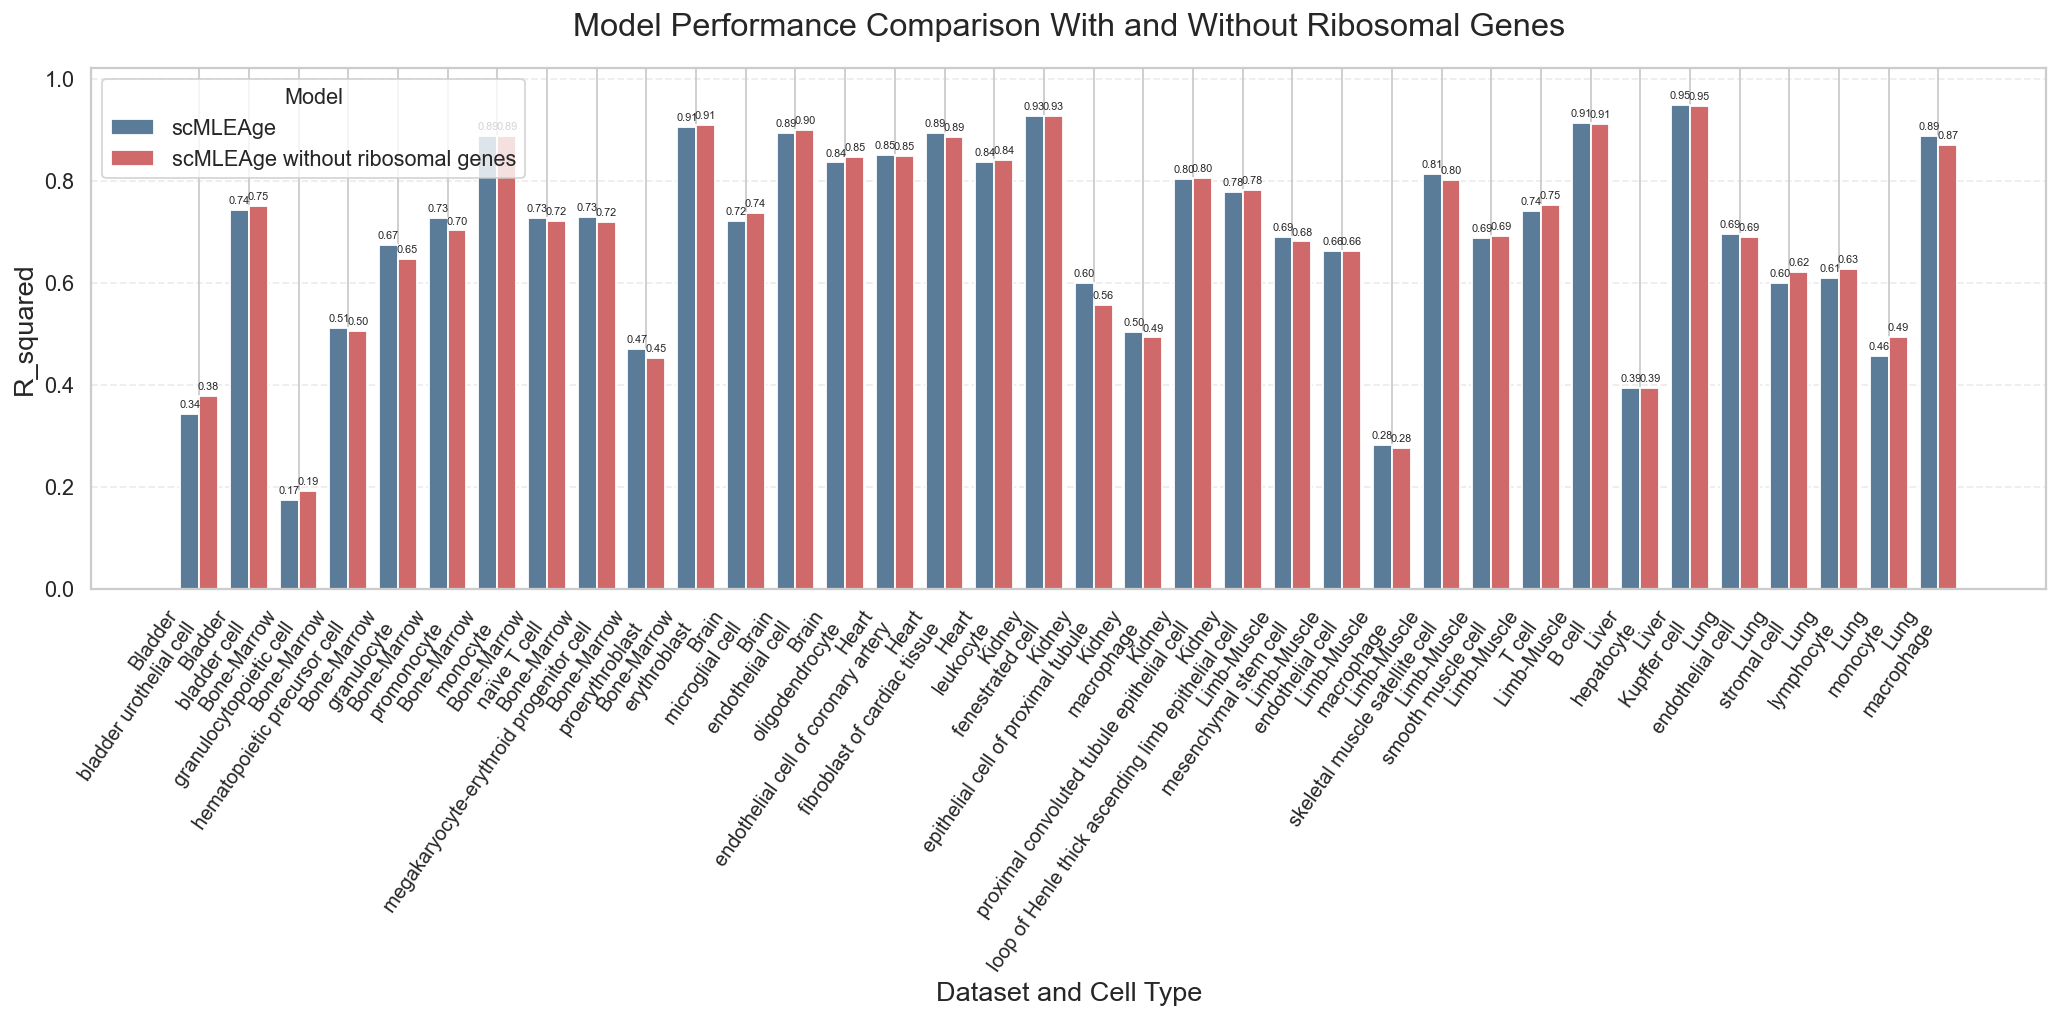

'./model_comparison.png'

In [15]:
datasets_to_plot = shared_keys
combined_comparison_df = get_all_comparisons(datasets_to_plot)
output_path = "./model_comparison.png"

display(combined_comparison_df)
plot_combined_r_squared_comparison(combined_comparison_df, output_path=output_path, dpi=600)
output_path